# Objetivo do projeto e contexto (prever preços de carros para a empresa Cars 4 You).

# Import Libraries

In [2]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from math import ceil


# Create Meta Data

**carID:** An atribute that contains an identifier for each car.

**Brand:** The cars main brand (e.g., Ford, Toyota).

**model:** The car model.

**year:** The year of registration of the car.

**mileage:** The total reported distance travelled by the car (in miles).

**tax:** The amount of road tax (in £) that, in 2020, was applicable to the car in question.

**fuelType:** Type of Fuel used by car (Diesel, Petrol, Hybrid, Electric).

**mpg:** Average Miles per Gallon.

**engineSize:** Size of Engine in liters (Cubic Decimeters).

**paintQuality%** The mechanic’s assessment of the cars’ overall paint quality and hull integrity (filled by the mechanic during evaluation). 

**previousOwner:** Number of previous registered owners of the vehicle.

**hasDamage:** Boolean marker filled by the seller at the time of registration stating whether the car is damaged or not.

**price:** The car's price when purchased by Cars 4 You (in £).

# Import Dataset

In [3]:
sample = pd.read_csv('../data/sample_submission.csv')
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

# EDA (Exploratory Data Analysis)

## Define new index for our datasets

In [4]:
sample.set_index('carID', inplace = True)
train.set_index('carID', inplace = True)
test.set_index('carID', inplace = True)

## Sample

In [5]:
print("Initial Analysis of the Sample Submission Dataset")
print('')
print(sample.shape)
print('-----------------------')
print(sample.head())
print('-----------------------')
print(sample.tail())

Initial Analysis of the Sample Submission Dataset

(32567, 1)
-----------------------
         price
carID         
89856   851000
106581  514000
80886   323000
100174  921000
81376   620000
-----------------------
         price
carID         
105775  412000
81363   441000
76833   684000
91768   835000
99627     2000


In [6]:
print("Continue to analyse the Sample Submission Dataset")
print('------------------------')
print('')
print(sample.info()) #From this output we can see that this dataset hasn't missing values
print('')
print('------------------------')
print(sample.describe())

Continue to analyse the Sample Submission Dataset
------------------------

<class 'pandas.core.frame.DataFrame'>
Index: 32567 entries, 89856 to 99627
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   price   32567 non-null  int64
dtypes: int64(1)
memory usage: 508.9 KB
None

------------------------
               price
count   32567.000000
mean   498198.943716
std    288111.809635
min      1000.000000
25%    249000.000000
50%    501000.000000
75%    746000.000000
max    999000.000000


## Train

In [7]:
train.shape

(75973, 13)

In [8]:
train.head()

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0


In [9]:
train.tail()

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
37194,Mercedes,C Class,2015.0,13498,Manual,14480.0,etrol,125.0,53.3,2.0,78.0,0.0,0.0
6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.9,2.0,38.0,2.0,0.0
54886,Toyota,Aygo,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.0,1.0,57.0,3.0,0.0
860,Audi,Q3,2015.0,12990,Manual,69072.0,iesel,125.0,60.1,2.0,74.0,2.0,0.0
15795,Ford,Fiesta,2018.0,10495,Manual,16709.0,Petro,145.0,64.2,1.1,38.0,1.0,0.0


From the visualization of the head and tail of the data base we can already understand that some errors exist:

    - Missing values
    - Values that should be integers as floats (2020.0)
We will further analyse this using describe and info.

It's also possible to see that some strings have the same information written in different forms (Diesel, iesel; Mercedes, mercedes).
To solve this problem we will uniformize all the values in data preparation

In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75973 entries, 69512 to 15795
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           74452 non-null  object 
 1   model           74456 non-null  object 
 2   year            74482 non-null  float64
 3   price           75973 non-null  int64  
 4   transmission    74451 non-null  object 
 5   mileage         74510 non-null  float64
 6   fuelType        74462 non-null  object 
 7   tax             68069 non-null  float64
 8   mpg             68047 non-null  float64
 9   engineSize      74457 non-null  float64
 10  paintQuality%   74449 non-null  float64
 11  previousOwners  74423 non-null  float64
 12  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(1), object(4)
memory usage: 8.1+ MB


From info we can see that:

    - year as a float...
    - previousOwners, hasDamage also as floats but they should be integers and booleans respectively
    - Missing values in all features except the price 

What will we do?

    Analyse with describe to have a different view

In [11]:
train.describe()

,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
count,74482.000000,75973.000000,74510.000000,68069.000000,68047.000000,74457.000000,74449.000000,74423.000000,74425.0
mean,2017.096611,16881.889553,23004.184088,120.329078,55.152666,1.660136,64.590667,1.994580,0.0
std,2.208704,9736.926322,22129.788366,65.521176,16.497837,0.573462,21.021065,1.472981,0.0
min,1970.000000,450.000000,-58540.574478,-91.121630,-43.421768,-0.103493,1.638913,-2.345650,0.0
25%,2016.000000,10200.000000,7423.250000,125.000000,46.300000,1.200000,47.000000,1.000000,0.0
50%,2017.000000,14699.000000,17300.000000,145.000000,54.300000,1.600000,65.000000,2.000000,0.0
75%,2019.000000,20950.000000,32427.500000,145.000000,62.800000,2.000000,82.000000,3.000000,0.0
max,2024.121759,159999.000000,323000.000000,580.000000,470.800000,6.600000,125.594308,6.258371,0.0


From the numeric describe we can see that we have some weird values:

    1. negative mileage, tax, mpg, engineSize, previousOwners in the minimum value
    2. hasDamage is a boolean but we can see that instead of 0 and 1 we only have 0 and Nones*
    3. previousOwner has a float? Should we round it?

*check in the hasDamage column

What will we do:

    1. Count the number of negative values and decide if we should drop or change them.
    2. Replace the nones by 1's. (data-preparation)
    3. Count the number of float values and decide to drop or round them.

In [12]:
train.describe(include='object')

,Brand,model,transmission,fuelType
count,74452,74456,74451,74462
unique,72,735,40,34
top,Ford,Focus,Manual,Petrol
freq,14808,6353,38050,37995


From the categorical describe we can confirm that this columns also have missing values


### Unique Values

In [13]:
for column in train.columns:
    unique_values = train[column].unique()
    print(f"Unique values on the column '{column}': {unique_values}")
    print('-----------------------------------')
    print('')


Unique values on the column 'Brand': ['VW' 'Toyota' 'Audi' 'Ford' 'BMW' 'Skoda' 'Opel' 'Mercedes' 'FOR'
 'mercedes' 'Hyundai' 'w' 'ord' 'MW' 'bmw' nan 'yundai' 'BM' 'Toyot' 'udi'
 'Ope' 'AUDI' 'V' 'opel' 'pel' 'For' 'pe' 'Mercede' 'audi' 'MERCEDES'
 'OPEL' 'koda' 'FORD' 'Hyunda' 'W' 'Aud' 'vw' 'hyundai' 'skoda' 'ford'
 'TOYOTA' 'ercedes' 'oyota' 'toyota' 'SKODA' 'Skod' 'HYUNDAI' 'kod' 'v'
 'for' 'SKOD' 'aud' 'KODA' 'PEL' 'yunda' 'or' 'UDI' 'OYOTA' 'HYUNDA' 'mw'
 'OPE' 'mercede' 'ERCEDES' 'ercede' 'TOYOT' 'MERCEDE' 'ORD' 'ud' 'ope'
 'AUD' 'hyunda' 'skod' 'toyot']
-----------------------------------

Unique values on the column 'model': [' Golf' ' Yaris' ' Q2' ' FIESTA' ' 2 Series' '3 Series' ' A3' ' Octavia'
 ' Passat' ' Focus' ' Insignia' ' A Clas' ' Q3' ' Fabia' ' A Class' ' Ka+'
 ' 3 Series' ' GLC Class' ' I30' ' C Class' ' Polo' ' E Class' ' C Clas'
 ' Q5' ' Up' ' Fiesta' ' C-HR' ' Mokka X' ' Corsa' ' Astra' ' TT'
 ' 5 Series' ' Aygo' ' 4 Series' ' SLK' ' Viva' ' T-Roc' 'Focus'
 ' E

Comments on the results above for each feature:
- `Brand` have significant inconsistencies with case sensitivity, ('mercede', 'FOR'), and fragmented entries ('pel', 'udi').

- `Model` have a lot of variations due to leading/trailing spaces, inconsistent casing, typos ('Focu' instead of 'Focus'), and incomplete entries ('A Clas').

- `Year` have decimal/fractional values (e.g., 2023.36707842) suggests data encoding errors or floating-point artifacts. 

- `Price` have numeric and diverse.

- `Transmission` column with multiple variants and typos exist for common types (e.g., 'Manual', 'manua', 'anual'). 

- `Mileage` appears mostly clean and numeric

- `FuelType` have many spelling and case variations (e.g., 'Petrol', 'petrol', 'etrol') exist.

- `Tax` with negative and fractional values are suspicious. 

- `MPG` looks like contain outliers and invalid negative values.

- `EngineSize` includes some unusual negative and zero values that should be verified.

- `PaintQuality%` have some values greater than 100%, what is not possible.

- `PreviousOwners` contains unexpected negative/fractional values and NaNs.

- `HasDamage` is Binary flag with values 0 and NaN.

### Check for duplicates

In [14]:
train.duplicated().sum()
#We conclude there are 4 duplicates in the whole table and we decided to remove them
train = train.drop_duplicates()

### Count Values

In [15]:
for column in train.columns:
    count_values = train[column].value_counts()
    print(f"The number of the distinct values in the column '{column}' is: {count_values}")
    print('-----------------------------------')
    print('')

The number of the distinct values in the column 'Brand' is: Brand
Ford        14806
Mercedes    10754
VW           9780
Opel         8645
BMW          6968
            ...  
kod             2
TOYOT           1
SKOD            1
skod            1
toyot           1
Name: count, Length: 72, dtype: int64
-----------------------------------

The number of the distinct values in the column 'model' is: model
 Focus        6351
 C Class      4886
 Fiesta       4130
 Golf         3081
 Corsa        2182
              ... 
UP               1
 scal            1
 Fox             1
astra            1
 glb class       1
Name: count, Length: 735, dtype: int64
-----------------------------------

The number of the distinct values in the column 'year' is: year
2019.000000    20270
2017.000000    16144
2016.000000    11502
2018.000000    10303
2015.000000     5733
2020.000000     3174
2014.000000     2930
2013.000000     1902
2012.000000      478
2011.000000      318
2010.000000      241
2009.000000    

Most of all the comments that can be done from the results above were already done after the .unique() analysis. 
With both this analysis we are planning to do the following for each feature:

- `Brand`, `Model`, `Transmission` and `FuelType`: unify capitalization, spacing and correct spelling errors and inconsistent spellings.

- `Year`: convert all values to integers and fix or remove non-sensical decimal values.

- `Price`: drop from the dataset and assign to a target variable.

- `Mileage`, `Tax`, `MPG`, `EngineSize` and `PreviousOwners`: ensure values are numeric and postive, detect and handle unrealistic or extreme values (e.g., negative, float or abnormall values in the feature context).

- `PaintQuality%`: cap values between 0 and 100.

- `HasDamage`: maybe assign the nan values to 1 cause we only have 0's and this should be a boolean feature.

Besides all this notes we need also to consider all the missing value noticed before on the DataFrame.


### GroupBy

In [16]:
train.groupby('hasDamage')['price'].mean()

hasDamage
0.0    16883.327287
Name: price, dtype: float64

From the code before we can see that the price mean for the cars that have no damage is 16883.212509.

It would also make sense to analyse the mean price of the cars with damage but the problem is that we can't assume to have cars with damage, because the column with the feature hasDamge has no 1's. This way it's impossible to check the mean price of the cars with damage.

In [17]:
train.groupby('mileage')['price'].mean()
#Here we can check a decrease of the price with the increase of the mileages
#But we still have the problem of the negatives mileages

mileage
-58540.574478     20806.384615
-52618.457894     21396.384615
-50755.210230     24644.259259
-48190.655673     16693.125000
-46497.584838     12386.826087
                      ...     
 241565.000000     2750.000000
 250650.000000     1485.000000
 259000.000000     6949.000000
 300000.000000     1190.000000
 323000.000000     2490.000000
Name: price, Length: 34808, dtype: float64

In [18]:
train.groupby('year')['price'].mean()
#It's possible to verify that the price varies depending ont he year of manufacture of the cars. 
#This is, the older the car, he cheaper it is

year
1970.000000    17747.000000
1996.000000     3000.000000
1997.000000     6972.500000
1998.000000    10183.800000
1999.000000     3986.000000
2000.000000     3869.166667
2001.000000     4401.000000
2002.000000     3206.920000
2003.000000     3452.517241
2004.000000     4179.914286
2005.000000     3007.468750
2006.000000     3958.580645
2007.000000     3454.910569
2008.000000     3913.069620
2009.000000     4141.008772
2009.816757    19686.486486
2010.000000     5016.514523
2010.268635    12568.100000
2010.371546    24268.114286
2010.565009    11370.425532
2010.676968    12834.268293
2010.746403    18257.810345
2011.000000     6771.940252
2011.111188    13038.466667
2011.210853    22981.640000
2012.000000     7601.456067
2012.695740    12633.095238
2013.000000     8503.491062
2014.000000    10025.783276
2015.000000    11654.296180
2016.000000    13357.350287
2017.000000    14475.293360
2018.000000    16314.916238
2019.000000    23530.970005
2020.000000    28523.561122
2022.696685    

In [19]:
!!!!! O CÓDIGO A SEGUIR FORAM RACIOCÍNEOS QUE FIZ QUE PODIAM DAR RESULTADOS GIROS MAS QUE NÃO SEI SE VALE A PENA POR  !!!!

train.groupby('previousOwners')['price'].mean()
#aqui podiamos relacionar o aumento do nº de donos com a diminuição do preço mas acho que os resultados não mostram nada muito
#interessante, não sei se vale a pena por

train.groupby('Brand')['price'].mean()
#pode ser interessante ver depois de ter corrigido o problema dos erros na escrita de cada marca. 
# é claro pelo resultado que por exemplo os yundais sao mais baratos que maior parte das outras marcas

train.groupby('paintQuality%')['price'].mean()
#acho que o resultado não mostra nada que tenha uma boa conclusao

paintQuality%
1.638913      13075.947368
1.769474      16913.340000
2.725153      14631.666667
3.115295      23080.937500
3.140370      23317.275000
                  ...     
125.301945    19645.741935
125.366507    18723.640000
125.453599    12116.434783
125.569499    21020.290323
125.594308    12144.960000
Name: price, Length: 88, dtype: float64

In [20]:
!!!!! O CÓDIGO A SEGUIR FORAM RACIOCÍNEOS QUE FIZ QUE PODIAM DAR RESULTADOS GIROS MAS QUE NÃO SEI SE VALE A PENA POR  !!!!

train.groupby('year')['paintQuality%'].mean()
#poderiamos ver que quanto mais velho o carro pior a qualidade de pintura, mas acho que isso não é muito explicito pelos resultados

train.groupby('previousOwners')['paintQuality%'].mean()
#os resultados tb nao permitem concluir nada

train.groupby('hasDamage')['paintQuality%'].mean()
#acho que aqui era giro comparar a qualidade de pintura com os carros que têm e não têm estragos mas como só temos missing values nos sitios dos 1's nao conseguimos concluir nada disso



hasDamage
0.0    64.594692
Name: paintQuality%, dtype: float64

### Correlation between variables

In [21]:
numeric_features = train.select_dtypes(include=['int64', 'float64'])
numeric_features.corr(method="pearson")

,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
year,1.000000,0.475713,-0.669434,0.179039,-0.123275,-0.038415,0.004132,0.000469,NaN
price,0.475713,1.000000,-0.405268,0.297109,-0.285646,0.612244,0.000243,-0.000007,NaN
mileage,-0.669434,-0.405268,1.000000,-0.202247,0.166993,0.099190,-0.001479,0.001720,NaN
tax,0.179039,0.297109,-0.202247,1.000000,-0.418807,0.256725,0.006463,0.002579,NaN
mpg,-0.123275,-0.285646,0.166993,-0.418807,1.000000,-0.227497,-0.002674,-0.001183,NaN
engineSize,-0.038415,0.612244,0.099190,0.256725,-0.227497,1.000000,0.005100,0.000814,NaN
paintQuality%,0.004132,0.000243,-0.001479,0.006463,-0.002674,0.005100,1.000000,-0.006257,NaN
previousOwners,0.000469,-0.000007,0.001720,0.002579,-0.001183,0.000814,-0.006257,1.000000,NaN
hasDamage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


From the code before it's difficult to get conclusions. We will visualize this matrix in a easy way of getting conclusions.

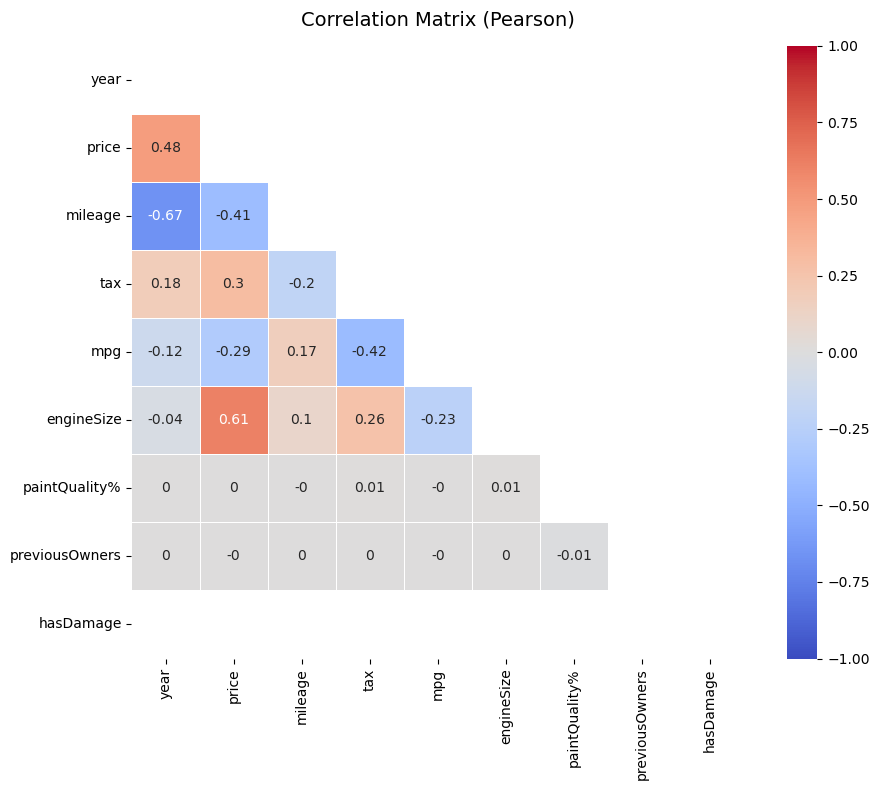

In [22]:
corr = numeric_features.corr(method="pearson").round(2)

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Visualize correlation matrix
fig = plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    mask=mask,                # hide upper triangle
    annot=True,               # show values
    cmap="coolwarm",          # divergent color map
    center=0,                 # center colormap in 0
    linewidths=0.5,           # lines between cells to help visualization
    vmin=-1, vmax=1,          # fix scale
    square=True               # make cells square-shaped
)


plt.title("Correlation Matrix (Pearson)", fontsize=14, pad=15)
plt.tight_layout() # improve layout by reducing overlaps
plt.show()


So from the first correlation analysis we can say that our model’s most important numerical predictors will likely be:
- year, mileage, engineSize
- tax and mpg might add secondary predictive power.
- paintQuality%, previousOwners, and hasDamage probably won’t help much unless cleaned or reinterpreted.

### Descriptive Statistics and Visualizations

This section starts by split our data in metric and non-metric features

In [23]:
non_numeric_features = train.select_dtypes(include=['object'])
#The variable associated to the numeric features was already created before with the name numeric_features

print("Numeric Features:")
for i, feature in enumerate(numeric_features, 1):
    print(f" {i}. {feature}")

print("\nCategorical Features:")
for i, feature in enumerate(non_numeric_features, 1):
    print(f" {i}. {feature}")

Numeric Features:
 1. year
 2. price
 3. mileage
 4. tax
 5. mpg
 6. engineSize
 7. paintQuality%
 8. previousOwners
 9. hasDamage

Categorical Features:
 1. Brand
 2. model
 3. transmission
 4. fuelType


Now we do the histograms for each numeric feature.

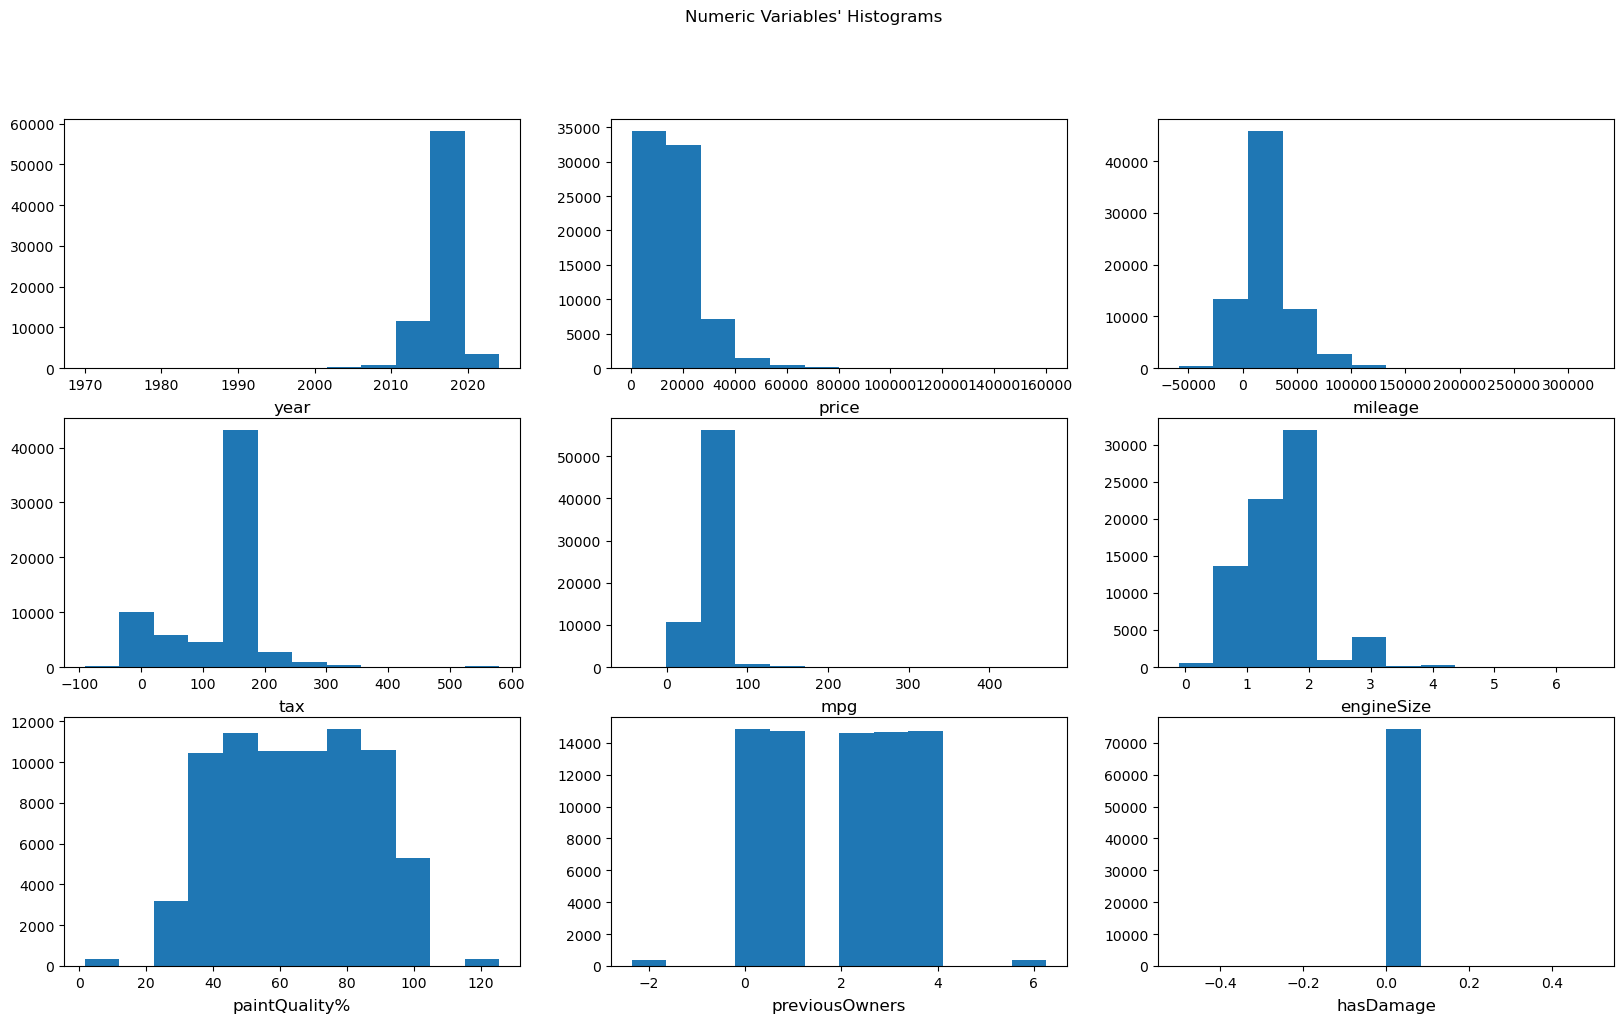

In [24]:
sp_rows = 3
sp_cols = 3

fig, axes = plt.subplots(sp_rows, 
                         sp_cols, 
                         figsize=(20, 11))

# Plot data
# Iterate across axes objects and associate each histogram
for ax, feat in zip(axes.flatten(), numeric_features):
    ax.hist(train[feat], bins=12) # 12 bins to accomodate the feature 'month' and because no interpretability in the other graphs is lost
    ax.set_title(feat, y=-0.21)
    
# Layout
# Add a centered title to the figure:
title = "Numeric Variables' Histograms"

plt.suptitle(title)

if not os.path.exists(os.path.join('..', 'figures', 'eda')):
    # if the exp_analysis directory is not present then create it first
    os.makedirs(os.path.join('..', 'figures', 'eda'))
    
plt.savefig(os.path.join('..', 'figures', 'eda', 'numeric_variables_histograms.png'), dpi=200)

plt.show()

Now we do the boxplot for each numeric feature.

##What do these do?
sp_rows = 2
sp_cols = ceil(len(numeric_features) / sp_rows)


#Prepare figure. Create individual axes where each histogram will be placed
fig, axes = plt.subplots(sp_rows, 
                         sp_cols, 
                         figsize=(20, 11),
                         tight_layout=False
                        )

#Plot data
#Iterate across axes objects and associate each histogram (hint: use the ax.hist() instead of plt.hist()):
for ax, feat in zip(axes.flatten(), numeric_features): #Notice the zip() function and flatten() method
    sns.boxplot(x=numeric_features[feat], ax=ax)
    
#Layout
#Add a centered title to the figure:
title = "Numeric Variables' Box Plots"

plt.suptitle(title)

if not os.path.exists(os.path.join('..', 'figures', 'eda')):
    #if the eda directory is not present then create it first
    os.makedirs(os.path.join('..', 'figures', 'eda'))


plt.savefig(os.path.join('..', 'figures', 'eda', 'numeric_variables_boxplots.png'), dpi=200)


plt.show()

## Define the independent variables as X and the dependent as Y

In [ ]:
X = train.drop('price', axis = 1)
y = train['price']

TO DO:
- corrigir types
- remover outliers graves, que são erros e visualizar boxplots
- Feature engineering: Criar features que não envolvem cálculos c/ média, mediana, …
Fazer tudo isto para o training and test set

### Split the dataset into train and validation

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X,y, test_size = 0.3, 
                                                  random_state = 0, 
                                                  #stratify = y- não pus esta parte como no notebook pq estava a dar erro e acho que é pq a nossa variavel y aqui não é um boolean mas sim um float
                                                  shuffle = True)

TO DO:

- Feature engineering: Criar features que envolvem cálculos c/ média, mediana, … (fazer para os 3 sets que temos)
- Preencher missing values nos 3 datasets, acho que dá para usar uma função ‘transform’ (justificar para depois por no report)  
!!!!!ATENÇÃO: os valores de média, moda,… a usar neste últimos dois passos são todos retirados apenas do training set e não do validation set

### Fill missing values

As we saw there are missing values in a couple of variables so we will fill the categories missing values with 'Unknow' and the numericals with the average.

But before do that we'll split our columns in metric and non_metric features.

In [ ]:
for column in ['Brand', 'model', 'transmission', 'fuelType']:
    X_train[column] = X_train[column].fillna('Unknown')
    X_val[column] = X_val[column].fillna('Unknown')

In [ ]:
for column in X_train.columns:
    if pd.api.types.is_numeric_dtype(X_train[column]):
        
        #store mean of training data in a variable - in a real application, you may need to store these values for future usages on e.g. test data 
        mean_to_fill = X_train[column].mean()
        
        #fill on X_train
        X_train[column].fillna(mean_to_fill, inplace=True)
        #Fill on X_val
        X_val[column].fillna(mean_to_fill, inplace=True)

/var/folders/s9/nfpy2jls4ps2k_p8lpjz6_yr0000gn/T/ipykernel_10288/626830012.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train[column].fillna(mean_to_fill, inplace=True)
/var/folders/s9/nfpy2jls4ps2k_p8lpjz6_yr0000gn/T/ipykernel_10288/626830012.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alw

## Test

In [ ]:
test.shape
#Here we can see that the test shape is equal to the sample shape.

(32567, 12)

In [ ]:
test.head(15)

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
89856,Hyundai,I30,2022.878006,Automatic,30700.000000,petrol,205.0,41.50000,1.6,61.0,3.0,0.0
106581,VW,Tiguan,2017.000000,Semi-Auto,-48190.655673,Petrol,150.0,38.20000,2.0,60.0,2.0,0.0
80886,BMW,2 Series,2016.000000,Automatic,36792.000000,Petrol,125.0,51.40000,1.5,94.0,2.0,0.0
100174,Opel,Grandland X,2019.000000,Manual,5533.000000,Petrol,145.0,44.10000,1.2,77.0,1.0,0.0
81376,BMW,1 Series,2019.000000,Semi-Auto,9058.000000,Diesel,150.0,51.40000,2.0,45.0,4.0,0.0
85391,Ford,Fiesta,2018.000000,Manual,29626.000000,Petrol,145.0,65.70000,1.0,64.0,1.0,0.0
82175,BMW,X1,2016.000000,Manual,57717.000000,Diese,125.0,58.90000,2.0,50.0,1.0,0.0
95250,Mercedes,B Class,2017.000000,Manual,14005.000000,Diesel,145.0,65.70000,NaN,64.0,4.0,0.0
85071,Ford,Focus,2011.000000,Manual,68274.000000,Petrol,145.0,47.90000,1.6,71.0,4.0,0.0


In [ ]:
test.tail(15)

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
90396,Hyundai,I10,2017.0,Manual,5970.00000,Petrol,150.0,60.1,1.0,75.0,0.0,0.0
97935,Toyota,Aygo,2019.0,Manual,10.00000,Petrol,145.0,56.5,1.0,89.0,2.0,0.0
80399,BMW,5 Series,2019.0,Automatic,1522.00000,Hybrid,135.0,141.3,2.0,38.0,3.0,0.0
105883,VW,Polo,2017.0,Manual,19812.00000,Petrol,145.0,60.1,1.2,71.0,1.0,0.0
92823,Mercedes,C Clas,2019.0,Semi-Auto,10545.00000,etrol,NaN,NaN,1.5,NaN,1.0,0.0
82238,BMW,i3,2017.0,AUTOMATIC,19178.00000,Other,0.0,470.8,0.6,43.0,0.0,0.0
98091,Toyota,Prius,2016.0,Automatic,28000.00000,hybrid,0.0,85.6,1.8,46.0,4.0,0.0
87257,Ford,Fiesta,2017.0,Semi-Auto,4512.00000,Petrol,0.0,57.7,1.0,35.0,0.0,0.0
87937,Ford,Fiesta,2018.0,Manual,10297.00000,Petrol,150.0,64.2,1.1,68.0,3.0,0.0


From the visualization of the head and tail of the data base we can already understand that some errors exist:

    - Missing values
    - Values in the columns Year, hasDamage, previousOwners that should be integers as floats (2020.0)
    - Floats on mpg, previousOwners column with diferent sizes
    - A category unknown in transmission column
    - It looks like the column hasDamage only contains 0's and blanks/None values, are the blanks supose to be 1's?
    - PreviousOwner and tax: negative values are impossible
We will further analyse this using describe and info.

It's also possible to see that some strings have the same information written in different forms (Petrol as etrol, Automatic and AUTOMATIC).
To solve this problem we will uniformize all the values in data preparation

In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32567 entries, 89856 to 99627
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           31918 non-null  object 
 1   model           31917 non-null  object 
 2   year            31914 non-null  float64
 3   transmission    31944 non-null  object 
 4   mileage         31878 non-null  float64
 5   fuelType        31911 non-null  object 
 6   tax             29259 non-null  float64
 7   mpg             29279 non-null  float64
 8   engineSize      31939 non-null  float64
 9   paintQuality%   31942 non-null  float64
 10  previousOwners  31970 non-null  float64
 11  hasDamage       31970 non-null  float64
dtypes: float64(8), object(4)
memory usage: 3.2+ MB


From info we can see that:

    - year, as a float...
    - previousOwners, hasDamage also as floats but they should be integers and booleans respectively
    - Missing values in all features

What will we do?

    Analyse with describe to have a different view

In [ ]:
test.describe()

,year,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
count,31914.000000,31878.000000,29259.000000,29279.000000,31939.000000,31942.000000,31970.000000,31970.0
mean,2017.102299,22952.658921,120.569239,55.210728,1.665377,64.446667,2.006118,0.0
std,2.207969,22132.758713,65.560570,17.644635,0.574467,21.142188,1.472310,0.0
min,1991.000000,-58540.574478,-91.121630,-43.421768,-0.103493,1.638913,-2.345650,0.0
25%,2016.000000,7298.250000,125.000000,46.300000,1.200000,47.000000,1.000000,0.0
50%,2017.000000,17225.500000,145.000000,54.300000,1.600000,65.000000,2.000000,0.0
75%,2019.000000,32500.000000,145.000000,62.800000,2.000000,82.000000,3.000000,0.0
max,2024.121759,279000.000000,580.000000,470.800000,6.600000,125.594308,6.258371,0.0


From the numeric describe we can see that we have some weird values:

    1. negative mileage, tax, mpg, engineSize, previousOwners in the minimum value
    2. hasDamage is a boolean but we can see that instead of 0 and 1 we only have 0 and Nones*
    3. previousOwner has a float? Should we round it?

*check in the hasDamage column

What will we do:

    1. Count the number of negative values and decide if we should drop or change them.
    2. Replace the nones by 1's. (data-preparation)
    3. Count the number of float values and decide to drop or round them.

In [ ]:
test.describe(include='object')

,Brand,model,transmission,fuelType
count,31918,31917,31944,31911
unique,64,593,38,29
top,Ford,Focus,Manual,Petrol
freq,6360,2721,16312,16113


From the categorical describe we tell that:

    - This columns also have missing values
    - transmission has 38 unique values and fuelType has 29...


In [ ]:
train.unique()

AttributeError: 'DataFrame' object has no attribute 'unique'

# Data Preprocessing

What should we do with the negative values? First of all we'll analyse them.

In [ ]:
mileage_train_negatives = train['mileage']<0
tax_train_negatives = train['tax']<0
mpg_train_negatives = train['mpg']<0
engineSize_train_negatives = train['engineSize']<0
previousOwners_train_negatives = train['previousOwners']<0


#here we used chatGPT to help us to construct the following DataFrame
negatives_summary = pd.DataFrame({
    'mileage_negatives': mileage_train_negatives.value_counts(),
    'tax_negatives': tax_train_negatives.value_counts(),
    'mpg_negatives': mpg_train_negatives.value_counts(),
    'engineSize_negatives': engineSize_train_negatives.value_counts(),
    'previousOwners_negatives': previousOwners_train_negatives.value_counts()
})

negatives_summary

In [ ]:
#Check the percentage of negative mileage values
data_len = len(train['mileage'])

#Here we used chatGPT to help us constructing the final negatives_table
negatives_percent = {
    'mileage_negatives (%)': mileage_train_negatives.sum() / data_len * 100,
    'tax_negatives (%)': tax_train_negatives.sum() / data_len * 100,
    'mpg_negatives (%)': mpg_train_negatives.sum() / data_len * 100,
    'engineSize_negatives (%)': engineSize_train_negatives.sum() / data_len * 100,
    'previousOwners_negatives (%)': previousOwners_train_negatives.sum() / data_len * 100
}

# Converter para DataFrame (tabela)
negatives_table = pd.DataFrame(negatives_percent, index=['Percentage of Negatives']).round(3)

negatives_table

From the negatives_table we obtain very low percentages for each variable, lower than 1%. So it's possible to conclude that this values are a small part of our data and that if we drop them we don't loose veracity.

We can also see that the total percentage of negative values is lower then 5%.

In [ ]:
# The goal is to count the values that are floats, this is, the values that have decimals different than 0
# To do this we create a variable with only the values that have decimals cases different than 0, that is, 
#the values for which the remainder of the division by 1 is not 0
has_decimals = train['previousOwners'] % 1 != 0
print(has_decimals.sum())
#at the end we sum all those values to find how many "real" floats exist


has_decimals.sum() / data_len * 100 

In [ ]:
brand_same_size = train['Brand'].str.lower()
brand_same_size.value_counts().to_frame()

In [ ]:
mapping_brands = {
    'ord' : 'ford',
    'for' : 'ford',
    'ercedes' : 'mercedes',
    'mercede' : 'mercedes',
    'w' : 'vw',
    'v' : 'vw',
    'ope' : 'opel',
    'pel' : 'opel',
    'mw' : 'bmw',
    'aud' : 'audi',
    'udi' : 'audi',
    'bm' : 'bmw',
    'oyota' : 'toyota',
    'koda' : 'skoda',
    'skod' : 'skoda',
    'toyot' : 'toyota',
    'yundai' : 'hyundai',
    'hyunda' : 'hyundai',
    'ercede' : 'mercedes',
    'or' : 'ford',
    'pe' : 'opel',
    'yunda' : 'hyundai',
    'ud' : 'audi',
    'kod' : 'skoda'
}
#train['Brand'] = train['Brand].replace(mapping_brands)

podemos usar esta maneira ou uma biblioteca chamada fuzzy matching mas não sei se vai ser permitido

hasDamage column - replace None values by 1

In [ ]:
train['hasDamage']=train['hasDamage'].fillna(1) #do the same for test set?

In [ ]:
#validate the changes, isto podemos apagar depois
train['hasDamage'].value_counts() 

previousOwner column - round to transform float into int

In [ ]:
train['previousOwners'] = train['previousOwners'].round(0) #do the same for test set?

In [ ]:
train['previousOwners'].value_counts() #negative values remove or stay? isto podemos apagar depois

## Prepare Feature Engineering

### Normalize the categorical variables

- fazer tanto para o train como para o validation mas usando só os valores do train